# Opsi B : Sliding Window + HOG

Notebook ini mempertahankan dataset `Maxim37/hazy-pedestrian-detection` karena dataset INRIA tidak dapat diakses.
Pipeline utama:
1. Download/load dataset otomatis dari Hugging Face.
2. Split train/test.
3. Positive patch extraction dengan context dan aspect ratio 64:128.
4. Random negative patches.
5. Initial Linear SVM.
6. Hard-negative mining dari citra training saja.
7. Final Linear SVM.
8. Dense multi-scale sliding window.
9. NMS.
10. AP@0.5.
11. Miss Rate vs FPPW dari raw sliding-window detections sebelum NMS.
12. Studi parameter HOG: cell size, orientation bins, dan block normalization.

In [14]:
# ============================================================
# 1. INSTALL & IMPORT
# ============================================================
!pip -q install -U datasets scikit-image scikit-learn joblib pandas matplotlib pillow

import os
import io
import gc
import time
import math
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from datasets import load_dataset
from skimage.feature import hog
from sklearn.svm import LinearSVC
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
print("Libraries ready.")

Libraries ready.


In [15]:
# ============================================================
# 2. REPRODUCIBILITY + GLOBAL CONFIGURATION
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Detector window mengikuti konfigurasi klasik pedestrian HOG.
WINDOW_W = 64
WINDOW_H = 128
WINDOW_ASPECT = WINDOW_W / WINDOW_H

# Final detector: lebih rapat daripada versi sebelumnya.
DETECT_STRIDE = 16

# Dense scale pyramid, tetapi tetap dibatasi agar runtime Colab masuk akal.
PYRAMID_SCALES = [1.00, 0.80]

# Training
MAX_POS_PATCHES = 2000
MAX_NEG_PATCHES = 2000

# Hard-negative mining
RUN_HARD_NEGATIVE_MINING = True
HNM_MAX_IMAGES = 100
HNM_STRIDE = 16
HNM_SCALES = [1.00, 0.85, 0.70]
HNM_TOPK_PER_IMAGE = 15
MAX_HARD_NEGATIVES = 1000
HNM_POSITIVE_IOU_LIMIT = 0.10

# SVM
SVM_C = 0.01
SVM_MAX_ITER = 10000

# Detection post-processing
NMS_IOU = 0.50
TOPK_PER_IMAGE = 300

# Final evaluation:
# None = seluruh test set.
# Untuk uji cepat dapat diganti misalnya 20.
TEST_LIMIT = 20

# Parallel CPU
N_JOBS = -1

print("Seed:", SEED)
print("Window:", (WINDOW_W, WINDOW_H))
print("Detection stride:", DETECT_STRIDE)
print("Pyramid:", PYRAMID_SCALES)

Seed: 42
Window: (64, 128)
Detection stride: 16
Pyramid: [1.0, 0.8]


## 3. Dataset

Dataset `Maxim37/hazy-pedestrian-detection` memiliki citra dan bounding-box pedestrian yang tersimpan sebagai koordinat ternormalisasi. Dataset viewer Hugging Face menunjukkan field `image`, `boxes`, `image_width`, dan `image_height`.

Karena dataset ini bukan INRIA Person, hasil tidak diklaim sebagai reproduksi angka Dalal–Triggs secara langsung. Fokus eksperimen adalah menguji pengaruh parameter HOG secara konsisten pada dataset yang dapat diakses.

In [16]:
# ============================================================
# 3. LOAD DATASET
# ============================================================
DATASET_ID = "Maxim37/hazy-pedestrian-detection"

dataset = load_dataset(DATASET_ID)

print(dataset)
print("Available splits:", list(dataset.keys()))

train_ds = dataset["train"]

if "test" in dataset:
    test_ds = dataset["test"]
else:
    # Fallback hanya jika dataset tidak menyediakan test split.
    split = train_ds.train_test_split(test_size=0.15, seed=SEED)
    train_ds = split["train"]
    test_ds = split["test"]

print("Train:", len(train_ds))
print("Test :", len(test_ds))

# Tampilkan struktur satu sample agar schema terlihat di output notebook.
print("Train features:", train_ds.features)
print("Example keys:", train_ds[0].keys())

DatasetDict({
    train: Dataset({
        features: ['image', 'boxes', 'image_width', 'image_height'],
        num_rows: 1052
    })
    test: Dataset({
        features: ['image', 'boxes', 'image_width', 'image_height'],
        num_rows: 143
    })
})
Available splits: ['train', 'test']
Train: 1052
Test : 143
Train features: {'image': Image(mode=None, decode=True), 'boxes': List(List(Value('float32'), length=4)), 'image_width': Value('int32'), 'image_height': Value('int32')}
Example keys: dict_keys(['image', 'boxes', 'image_width', 'image_height'])


In [17]:
# ============================================================
# 4. DATASET UTILITIES
# ============================================================
def to_rgb_array(image_obj):
    """Convert HF/PIL image object to uint8 RGB numpy array."""
    if isinstance(image_obj, Image.Image):
        return np.asarray(image_obj.convert("RGB"))

    if isinstance(image_obj, dict):
        if image_obj.get("bytes") is not None:
            return np.asarray(Image.open(io.BytesIO(image_obj["bytes"])).convert("RGB"))
        if image_obj.get("path") is not None:
            return np.asarray(Image.open(image_obj["path"]).convert("RGB"))

    arr = np.asarray(image_obj)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    if arr.shape[-1] == 4:
        arr = arr[..., :3]
    return arr.astype(np.uint8)


def get_gt_boxes(example):
    """
    Dataset boxes are normalized:
    [x1, y1, x2, y2] in approximately [0, 1].
    Clip invalid annotation values before converting to pixels.
    """
    W = int(example["image_width"])
    H = int(example["image_height"])

    boxes = np.asarray(example["boxes"], dtype=np.float32)
    if boxes.size == 0:
        return []

    boxes = boxes.reshape(-1, 4)
    result = []

    for b in boxes:
        x1, y1, x2, y2 = b.tolist()

        # Clip malformed values that can occasionally exceed image bounds.
        x1 = np.clip(x1, 0.0, 1.0)
        y1 = np.clip(y1, 0.0, 1.0)
        x2 = np.clip(x2, 0.0, 1.0)
        y2 = np.clip(y2, 0.0, 1.0)

        px1 = int(round(x1 * W))
        py1 = int(round(y1 * H))
        px2 = int(round(x2 * W))
        py2 = int(round(y2 * H))

        if px2 > px1 and py2 > py1:
            result.append((px1, py1, px2, py2))

    return result


def resize_patch(patch):
    """Resize any patch to detector window size."""
    if patch.size == 0:
        return None
    img = Image.fromarray(patch.astype(np.uint8)).resize(
        (WINDOW_W, WINDOW_H), Image.Resampling.BILINEAR
    )
    return np.asarray(img, dtype=np.uint8)


def box_iou(a, b):
    """IoU for boxes in xyxy format."""
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)

    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def max_iou(box, gt_boxes):
    if not gt_boxes:
        return 0.0
    return max(box_iou(box, g) for g in gt_boxes)

In [18]:
# ============================================================
# 5. CONTEXT-AWARE POSITIVE PATCH
# ============================================================
def crop_with_context(image, bbox, context=0.20):
    """
    Expand bbox, then pad around it so the crop has detector
    aspect ratio 64:128. This reduces geometric distortion.
    """
    H, W = image.shape[:2]
    x1, y1, x2, y2 = map(float, bbox)

    bw = max(1.0, x2 - x1)
    bh = max(1.0, y2 - y1)

    # Context expansion.
    x1 -= context * bw
    x2 += context * bw
    y1 -= context * bh
    y2 += context * bh

    cx = 0.5 * (x1 + x2)
    cy = 0.5 * (y1 + y2)
    crop_w = max(2.0, x2 - x1)
    crop_h = max(2.0, y2 - y1)

    # Force target aspect ratio.
    target_ratio = WINDOW_ASPECT

    if crop_w / crop_h > target_ratio:
        crop_h = crop_w / target_ratio
    else:
        crop_w = crop_h * target_ratio

    x1 = cx - crop_w / 2
    x2 = cx + crop_w / 2
    y1 = cy - crop_h / 2
    y2 = cy + crop_h / 2

    # Shift crop into image boundaries where possible.
    if x1 < 0:
        x2 -= x1
        x1 = 0
    if y1 < 0:
        y2 -= y1
        y1 = 0
    if x2 > W:
        x1 -= (x2 - W)
        x2 = W
    if y2 > H:
        y1 -= (y2 - H)
        y2 = H

    x1 = max(0, int(round(x1)))
    y1 = max(0, int(round(y1)))
    x2 = min(W, int(round(x2)))
    y2 = min(H, int(round(y2)))

    if x2 <= x1 or y2 <= y1:
        return None

    return resize_patch(image[y1:y2, x1:x2])


def generate_positive_patches(ds, max_patches=MAX_POS_PATCHES):
    patches = []

    candidates = []
    for idx in range(len(ds)):
        ex = ds[idx]
        boxes = get_gt_boxes(ex)
        for b in boxes:
            candidates.append((idx, b))

    rng = np.random.default_rng(SEED)
    rng.shuffle(candidates)

    for idx, bbox in candidates[:max_patches]:
        image = to_rgb_array(ds[idx]["image"])
        patch = crop_with_context(image, bbox, context=0.20)
        if patch is not None:
            patches.append(patch)

    return patches


def generate_negative_patches(
    ds,
    max_patches=MAX_NEG_PATCHES,
    attempts_per_image=50,
    iou_threshold=0.05
):
    """Random fixed-ratio windows with very low IoU to GT boxes."""
    rng = np.random.default_rng(SEED + 1)
    negatives = []

    image_indices = np.arange(len(ds))
    rng.shuffle(image_indices)

    for idx in image_indices:
        if len(negatives) >= max_patches:
            break

        image = to_rgb_array(ds[int(idx)]["image"])
        H, W = image.shape[:2]
        gt = get_gt_boxes(ds[int(idx)])

        if H < WINDOW_H or W < WINDOW_W:
            continue

        for _ in range(attempts_per_image):
            if len(negatives) >= max_patches:
                break

            x1 = int(rng.integers(0, W - WINDOW_W + 1))
            y1 = int(rng.integers(0, H - WINDOW_H + 1))
            box = (x1, y1, x1 + WINDOW_W, y1 + WINDOW_H)

            if max_iou(box, gt) < iou_threshold:
                negatives.append(image[y1:y1+WINDOW_H, x1:x1+WINDOW_W].copy())

    return negatives


positive_patches = generate_positive_patches(train_ds)
negative_patches = generate_negative_patches(train_ds)

print("Positive patches:", len(positive_patches))
print("Negative patches:", len(negative_patches))

Positive patches: 2000
Negative patches: 2000


In [19]:
# ============================================================
# 6. HOG EXTRACTION
# ============================================================
def extract_hog_one(
    patch,
    cell_size=8,
    orientations=9,
    block_norm="L2-Hys"
):
    gray = np.asarray(
        Image.fromarray(patch).convert("L"),
        dtype=np.uint8
    )

    feat = hog(
        gray,
        orientations=orientations,
        pixels_per_cell=(cell_size, cell_size),
        cells_per_block=(2, 2),
        block_norm=block_norm,
        feature_vector=True
    )

    return feat.astype(np.float32)


def extract_hog_batch(
    patches,
    cell_size,
    orientations,
    block_norm
):
    feats = Parallel(
        n_jobs=N_JOBS,
        prefer="threads"
    )(
        delayed(extract_hog_one)(
            p,
            cell_size=cell_size,
            orientations=orientations,
            block_norm=block_norm
        )
        for p in patches
    )

    return np.asarray(feats, dtype=np.float32)


def train_linear_svm(X_pos, X_neg):
    X = np.vstack([X_pos, X_neg])
    y = np.hstack([
        np.ones(len(X_pos), dtype=np.int32),
        np.zeros(len(X_neg), dtype=np.int32)
    ])

    clf = LinearSVC(
        C=SVM_C,
        class_weight="balanced",
        max_iter=SVM_MAX_ITER,
        random_state=SEED
    )
    clf.fit(X, y)
    return clf

## 7. Sliding-window utilities

Inference memakai:
- window 64×128;
- stride 8;
- multi-scale pyramid;
- Linear SVM score;
- NMS hanya untuk visualisasi/AP, sedangkan DET curve memakai raw detections sebelum NMS.

In [20]:
# ============================================================
# 7. SLIDING WINDOW + IMAGE PYRAMID
# ============================================================
def resize_image_scale(image, scale):
    H, W = image.shape[:2]
    new_w = max(1, int(round(W * scale)))
    new_h = max(1, int(round(H * scale)))

    if new_w < WINDOW_W or new_h < WINDOW_H:
        return None

    return np.asarray(
        Image.fromarray(image).resize(
            (new_w, new_h),
            Image.Resampling.BILINEAR
        )
    )


def generate_windows(image, stride=DETECT_STRIDE):
    H, W = image.shape[:2]

    if W < WINDOW_W or H < WINDOW_H:
        return []

    windows = []
    for y in range(0, H - WINDOW_H + 1, stride):
        for x in range(0, W - WINDOW_W + 1, stride):
            windows.append(
                (x, y, x + WINDOW_W, y + WINDOW_H)
            )
    return windows


def score_windows(
    image_scaled,
    windows,
    model,
    cell_size,
    orientations,
    block_norm
):
    patches = [
        image_scaled[y1:y2, x1:x2]
        for (x1, y1, x2, y2) in windows
    ]

    if not patches:
        return np.empty((0,), dtype=np.float32)

    X = extract_hog_batch(
        patches,
        cell_size=cell_size,
        orientations=orientations,
        block_norm=block_norm
    )

    return model.decision_function(X).astype(np.float32)


def nms(detections, iou_threshold=NMS_IOU):
    if not detections:
        return []

    boxes = np.asarray([d["box"] for d in detections], dtype=np.float32)
    scores = np.asarray([d["score"] for d in detections], dtype=np.float32)

    order = scores.argsort()[::-1]
    keep = []

    while len(order) > 0:
        i = order[0]
        keep.append(int(i))

        if len(order) == 1:
            break

        rest = order[1:]
        ious = np.asarray([
            box_iou(boxes[i], boxes[j])
            for j in rest
        ])

        order = rest[ious < iou_threshold]

    return [detections[i] for i in keep]


def detect_image(
    image,
    model,
    cell_size,
    orientations,
    block_norm,
    scales=PYRAMID_SCALES,
    stride=DETECT_STRIDE,
    topk=TOPK_PER_IMAGE,
    return_all_raw=True
):
    """
    Returns raw sliding-window detections before NMS.
    Coordinates are mapped back to original image coordinates.
    """
    all_dets = []

    for scale in scales:
        scaled = resize_image_scale(image, scale)
        if scaled is None:
            continue

        windows = generate_windows(scaled, stride=stride)
        if not windows:
            continue

        scores = score_windows(
            scaled,
            windows,
            model,
            cell_size,
            orientations,
            block_norm
        )

        if len(scores) == 0:
            continue

        # Runtime-safe top-k after scoring, before NMS.
        k = min(topk, len(scores))
        idxs = np.argpartition(scores, -k)[-k:]
        idxs = idxs[np.argsort(scores[idxs])[::-1]]

        inv_scale = 1.0 / scale

        for i in idxs:
            score = float(scores[i])
            x1, y1, x2, y2 = windows[int(i)]

            box_original = (
                x1 * inv_scale,
                y1 * inv_scale,
                x2 * inv_scale,
                y2 * inv_scale
            )

            all_dets.append({
                "box": box_original,
                "score": score
            })

    all_dets.sort(key=lambda d: d["score"], reverse=True)

    if topk is not None:
        all_dets = all_dets[:topk]

    return all_dets

## 8. Hard-negative mining

Hard-negative mining dilakukan hanya pada data training agar test set tetap unseen.

Langkah-langkah:
1. train initial SVM;
2. scan sejumlah citra training;
3. ambil false positives dengan score tinggi;
4. buang window yang overlap dengan GT;
5. tambahkan hard negatives;
6. train final SVM.

In [21]:
# ============================================================
# 8. HARD-NEGATIVE MINING
# ============================================================
def mine_hard_negatives(
    ds,
    model,
    cell_size,
    orientations,
    block_norm,
    max_images=HNM_MAX_IMAGES,
    stride=HNM_STRIDE,
    scales=HNM_SCALES,
    topk_per_image=HNM_TOPK_PER_IMAGE,
    max_hard_negatives=MAX_HARD_NEGATIVES
):
    rng = np.random.default_rng(SEED + 123)
    indices = np.arange(len(ds))
    rng.shuffle(indices)
    indices = indices[:min(max_images, len(indices))]

    candidates = []

    for count, idx in enumerate(indices):
        ex = ds[int(idx)]
        image = to_rgb_array(ex["image"])
        gt = get_gt_boxes(ex)

        for scale in scales:
            scaled = resize_image_scale(image, scale)
            if scaled is None:
                continue

            windows = generate_windows(scaled, stride=stride)
            if not windows:
                continue

            scores = score_windows(
                scaled,
                windows,
                model,
                cell_size,
                orientations,
                block_norm
            )

            if len(scores) == 0:
                continue

            k = min(topk_per_image, len(scores))
            order = np.argsort(scores)[::-1][:k]

            inv_scale = 1.0 / scale

            for wi in order:
                score = float(scores[wi])
                if score <= 0:
                    continue

                x1, y1, x2, y2 = windows[int(wi)]
                box_original = (
                    x1 * inv_scale,
                    y1 * inv_scale,
                    x2 * inv_scale,
                    y2 * inv_scale
                )

                # Must be background, not a poorly localized positive.
                if max_iou(box_original, gt) >= HNM_POSITIVE_IOU_LIMIT:
                    continue

                patch = scaled[y1:y2, x1:x2]
                if patch.shape[0] != WINDOW_H or patch.shape[1] != WINDOW_W:
                    continue

                candidates.append(
                    (score, patch.copy())
                )

        if count % 10 == 0:
            print(
                f"HNM image {count+1}/{len(indices)} | "
                f"candidates={len(candidates)}"
            )

    # Highest-scoring false positives first.
    candidates.sort(key=lambda z: z[0], reverse=True)
    selected = [
        patch for _, patch in candidates[:max_hard_negatives]
    ]

    return selected


def fit_detector_config(
    config,
    positive_patches,
    negative_patches,
    train_ds
):
    cell = config["cell_size"]
    bins = config["orientations"]
    norm = config["block_norm"]

    print("\n" + "=" * 70)
    print("TRAINING:", config["name"])
    print("=" * 70)

    t0 = time.time()

    X_pos = extract_hog_batch(
        positive_patches,
        cell,
        bins,
        norm
    )

    X_neg = extract_hog_batch(
        negative_patches,
        cell,
        bins,
        norm
    )

    print("Positive features:", X_pos.shape)
    print("Negative features:", X_neg.shape)

    # Initial model.
    initial_model = train_linear_svm(X_pos, X_neg)

    hard_negatives = []
    if RUN_HARD_NEGATIVE_MINING:
        print("Mining hard negatives...")
        hard_negatives = mine_hard_negatives(
            train_ds,
            initial_model,
            cell,
            bins,
            norm
        )
        print("Hard negatives:", len(hard_negatives))

    if hard_negatives:
        X_hard = extract_hog_batch(
            hard_negatives,
            cell,
            bins,
            norm
        )
        X_neg_final = np.vstack([X_neg, X_hard])
    else:
        X_neg_final = X_neg

    final_model = train_linear_svm(
        X_pos,
        X_neg_final
    )

    train_time = time.time() - t0

    print("Final negative features:", X_neg_final.shape)
    print("Training time: %.2f s" % train_time)

    return {
        "model": final_model,
        "config": config,
        "train_time": train_time,
        "feature_dim": X_pos.shape[1],
        "n_pos": len(X_pos),
        "n_neg": len(X_neg_final),
        "n_hard_neg": len(hard_negatives)
    }

## 9. Parameter study

Parameter HOG
Konfigurasi:
- Baseline: 8×8, 9 bins, L2-Hys
- Cell 6×6
- Cell 4×4
- 6 orientation bins
- 12 orientation bins
- L2 block normalization

In [22]:
# ============================================================
# 9. EXPERIMENT CONFIGURATIONS
# ============================================================
EXPERIMENTS = [
    {
        "name": "Baseline_8x9_L2Hys",
        "cell_size": 8,
        "orientations": 9,
        "block_norm": "L2-Hys"
    },
    {
        "name": "Cell_6x6_L2Hys",
        "cell_size": 6,
        "orientations": 9,
        "block_norm": "L2-Hys"
    },
    {
        "name": "Cell_4x4_L2Hys",
        "cell_size": 4,
        "orientations": 9,
        "block_norm": "L2-Hys"
    },
    {
        "name": "Bins_6_L2Hys",
        "cell_size": 8,
        "orientations": 6,
        "block_norm": "L2-Hys"
    },
    {
        "name": "Bins_12_L2Hys",
        "cell_size": 8,
        "orientations": 12,
        "block_norm": "L2-Hys"
    },
    {
        "name": "Norm_L2",
        "cell_size": 8,
        "orientations": 9,
        "block_norm": "L2"
    }
]

pd.DataFrame(EXPERIMENTS)

,name,cell_size,orientations,block_norm
0,Baseline_8x9_L2Hys,8,9,L2-Hys
1,Cell_6x6_L2Hys,6,9,L2-Hys
2,Cell_4x4_L2Hys,4,9,L2-Hys
3,Bins_6_L2Hys,8,6,L2-Hys
4,Bins_12_L2Hys,8,12,L2-Hys
5,Norm_L2,8,9,L2


In [23]:
# ============================================================
# 10. TRAIN ALL CONFIGURATIONS
# ============================================================
trained_models = {}

for cfg in EXPERIMENTS:
    trained_models[cfg["name"]] = fit_detector_config(
        cfg,
        positive_patches,
        negative_patches,
        train_ds
    )

gc.collect()

print("\nFinished training all configurations.")


TRAINING: Baseline_8x9_L2Hys
Positive features: (2000, 3780)
Negative features: (2000, 3780)
Mining hard negatives...
HNM image 1/100 | candidates=0
HNM image 11/100 | candidates=21
HNM image 21/100 | candidates=55
HNM image 31/100 | candidates=83
HNM image 41/100 | candidates=141
HNM image 51/100 | candidates=205
HNM image 61/100 | candidates=230
HNM image 71/100 | candidates=255
HNM image 81/100 | candidates=296
HNM image 91/100 | candidates=311
Hard negatives: 316
Final negative features: (2316, 3780)
Training time: 162.16 s

TRAINING: Cell_6x6_L2Hys
Positive features: (2000, 6480)
Negative features: (2000, 6480)
Mining hard negatives...
HNM image 1/100 | candidates=0
HNM image 11/100 | candidates=20
HNM image 21/100 | candidates=46
HNM image 31/100 | candidates=75
HNM image 41/100 | candidates=132
HNM image 51/100 | candidates=189
HNM image 61/100 | candidates=224
HNM image 71/100 | candidates=244
HNM image 81/100 | candidates=293
HNM image 91/100 | candidates=315
Hard negatives: 

## Ground truth test set



In [24]:
# ============================================================
# 11. TEST SET + GROUND TRUTH
# ============================================================
if TEST_LIMIT is None:
    test_indices = list(range(len(test_ds)))
else:
    test_indices = list(range(min(TEST_LIMIT, len(test_ds))))

gt_by_image = {}
images_by_id = {}

for idx in test_indices:
    image = to_rgb_array(test_ds[idx]["image"])
    gt = get_gt_boxes(test_ds[idx])

    image_id = int(idx)
    images_by_id[image_id] = image
    gt_by_image[image_id] = gt

total_gt = sum(len(v) for v in gt_by_image.values())

print("Test images:", len(test_indices))
print("Total GT boxes:", total_gt)

Test images: 20
Total GT boxes: 38


In [25]:
# ============================================================
# 12. SMOKE TEST
# ============================================================
valid_smoke_id = None

for image_id in test_indices:
    H, W = images_by_id[image_id].shape[:2]
    if H >= WINDOW_H and W >= WINDOW_W:
        valid_smoke_id = image_id
        break

assert valid_smoke_id is not None, "Tidak ada test image yang cukup besar untuk window 64x128."

smoke_name = EXPERIMENTS[0]["name"]
smoke_info = trained_models[smoke_name]

smoke_dets = detect_image(
    images_by_id[valid_smoke_id],
    smoke_info["model"],
    smoke_info["config"]["cell_size"],
    smoke_info["config"]["orientations"],
    smoke_info["config"]["block_norm"],
    scales=PYRAMID_SCALES,
    stride=DETECT_STRIDE,
    topk=TOPK_PER_IMAGE
)

print("Smoke test image:", valid_smoke_id)
print("Image shape:", images_by_id[valid_smoke_id].shape)
print("Raw/top-k detections:", len(smoke_dets))
print("Top scores:", [round(d["score"], 4) for d in smoke_dets[:10]])

assert len(smoke_dets) > 0, (
    "Smoke test menghasilkan 0 detections. "
    "Periksa ukuran image, model, atau HOG configuration."
)

Smoke test image: 1
Image shape: (144, 139, 3)
Raw/top-k detections: 10
Top scores: [1.3105, 0.9116, 0.8325, 0.5702, 0.3237, 0.1873, 0.0845, -0.0954, -0.1938, -0.6556]


In [26]:
# ============================================================
# 13. DETECTION ON TEST SET
# ============================================================
def run_test_detection(info, test_indices, images_by_id):
    cfg = info["config"]
    model = info["model"]

    raw_predictions = {}
    nms_predictions = {}

    t0 = time.time()

    for n, image_id in enumerate(test_indices):
        image = images_by_id[image_id]

        raw = detect_image(
            image,
            model,
            cfg["cell_size"],
            cfg["orientations"],
            cfg["block_norm"],
            scales=PYRAMID_SCALES,
            stride=DETECT_STRIDE,
            topk=TOPK_PER_IMAGE
        )

        raw_predictions[image_id] = raw
        nms_predictions[image_id] = nms(raw, NMS_IOU)

        if (n + 1) % 10 == 0 or n == 0:
            print(
                f"{cfg['name']}: {n+1}/{len(test_indices)} images"
            )

    elapsed = time.time() - t0

    return raw_predictions, nms_predictions, elapsed


all_results = {}

for name, info in trained_models.items():
    raw_pred, nms_pred, det_time = run_test_detection(
        info,
        test_indices,
        images_by_id
    )

    all_results[name] = {
        "raw": raw_pred,
        "nms": nms_pred,
        "detection_time": det_time
    }

    print(
        f"{name}: detection time = {det_time:.2f} s"
    )

gc.collect()

Baseline_8x9_L2Hys: 1/20 images
Baseline_8x9_L2Hys: 10/20 images
Baseline_8x9_L2Hys: 20/20 images
Baseline_8x9_L2Hys: detection time = 17.17 s
Cell_6x6_L2Hys: 1/20 images
Cell_6x6_L2Hys: 10/20 images
Cell_6x6_L2Hys: 20/20 images
Cell_6x6_L2Hys: detection time = 22.95 s
Cell_4x4_L2Hys: 1/20 images
Cell_4x4_L2Hys: 10/20 images
Cell_4x4_L2Hys: 20/20 images
Cell_4x4_L2Hys: detection time = 48.86 s
Bins_6_L2Hys: 1/20 images
Bins_6_L2Hys: 10/20 images
Bins_6_L2Hys: 20/20 images
Bins_6_L2Hys: detection time = 16.21 s
Bins_12_L2Hys: 1/20 images
Bins_12_L2Hys: 10/20 images
Bins_12_L2Hys: 20/20 images
Bins_12_L2Hys: detection time = 17.73 s
Norm_L2: 1/20 images
Norm_L2: 10/20 images
Norm_L2: 20/20 images
Norm_L2: detection time = 12.75 s


168

## 14. AP@0.5

AP dihitung dari seluruh detections setelah NMS:
1. sort berdasarkan SVM score;
2. cocokkan detection dengan GT IoU ≥ 0.5;
3. satu GT hanya boleh matched satu kali;
4. hitung precision-recall;
5. hitung interpolated AP.

In [27]:
# ============================================================
# 14. AP@0.5
# ============================================================
def compute_ap50(predictions, gt_by_image, iou_threshold=0.5):
    records = []

    total_gt = sum(len(v) for v in gt_by_image.values())
    if total_gt == 0:
        return 0.0

    for image_id, dets in predictions.items():
        for d in dets:
            records.append({
                "image_id": image_id,
                "box": d["box"],
                "score": float(d["score"])
            })

    records.sort(key=lambda x: x["score"], reverse=True)

    matched = {
        image_id: np.zeros(len(gt_by_image[image_id]), dtype=bool)
        for image_id in gt_by_image
    }

    tp = np.zeros(len(records), dtype=np.float64)
    fp = np.zeros(len(records), dtype=np.float64)

    for i, r in enumerate(records):
        gt = gt_by_image[r["image_id"]]

        if not gt:
            fp[i] = 1
            continue

        ious = np.asarray([
            box_iou(r["box"], g)
            for g in gt
        ])

        j = int(np.argmax(ious))

        if ious[j] >= iou_threshold and not matched[r["image_id"]][j]:
            tp[i] = 1
            matched[r["image_id"]][j] = True
        else:
            fp[i] = 1

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)

    recall = cum_tp / total_gt
    precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)

    # VOC-style precision envelope.
    mrec = np.concatenate([[0.0], recall, [1.0]])
    mpre = np.concatenate([[0.0], precision, [0.0]])

    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum(
        (mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]
    )

    return float(ap)

In [28]:
# ============================================================
# 15. MISS RATE vs FPPW
# ============================================================
def compute_det_curve(
    raw_predictions,
    gt_by_image,
    iou_threshold=0.5
):
    """
    Compute miss rate vs FPPW using RAW sliding-window detections.

    FPPW denominator:
        total number of sliding-window evaluations represented by
        raw_predictions.

    Because only top-k windows are retained for runtime, the notebook
    reports FPPW with respect to retained raw candidate windows.
    This is explicitly stated as an implementation limitation.
    """
    records = []

    for image_id, dets in raw_predictions.items():
        for d in dets:
            records.append({
                "image_id": image_id,
                "box": d["box"],
                "score": float(d["score"])
            })

    if not records:
        return pd.DataFrame()

    records.sort(key=lambda x: x["score"], reverse=True)

    total_gt = sum(len(v) for v in gt_by_image.values())
    total_windows = len(records)

    matched = {
        image_id: np.zeros(len(gt_by_image[image_id]), dtype=bool)
        for image_id in gt_by_image
    }

    tp = np.zeros(len(records), dtype=np.float64)
    fp = np.zeros(len(records), dtype=np.float64)

    for i, r in enumerate(records):
        gt = gt_by_image[r["image_id"]]

        if not gt:
            fp[i] = 1
            continue

        ious = np.asarray([
            box_iou(r["box"], g)
            for g in gt
        ])

        j = int(np.argmax(ious))

        if ious[j] >= iou_threshold and not matched[r["image_id"]][j]:
            tp[i] = 1
            matched[r["image_id"]][j] = True
        else:
            fp[i] = 1

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)

    recall = cum_tp / max(total_gt, 1)
    miss_rate = 1.0 - recall
    fppw = cum_fp / max(total_windows, 1)

    curve = pd.DataFrame({
        "score_threshold": [r["score"] for r in records],
        "miss_rate": miss_rate,
        "FPPW": fppw,
        "TP": cum_tp,
        "FP": cum_fp
    })

    # Keep monotonic ordering in FPPW.
    curve = curve.sort_values(
        ["FPPW", "score_threshold"],
        ascending=[True, False]
    ).drop_duplicates("FPPW")

    return curve.reset_index(drop=True)

In [29]:
# ============================================================
# 16. EVALUATE ALL CONFIGURATIONS
# ============================================================
summary_rows = []
det_curves = {}

for name, result in all_results.items():
    ap = compute_ap50(
        result["nms"],
        gt_by_image,
        iou_threshold=0.5
    )

    curve = compute_det_curve(
        result["raw"],
        gt_by_image,
        iou_threshold=0.5
    )

    det_curves[name] = curve

    info = trained_models[name]

    summary_rows.append({
        "Experiment": name,
        "Cell": info["config"]["cell_size"],
        "Bins": info["config"]["orientations"],
        "BlockNorm": info["config"]["block_norm"],
        "FeatureDim": info["feature_dim"],
        "TrainTime_s": info["train_time"],
        "DetectionTime_s": result["detection_time"],
        "PosPatches": info["n_pos"],
        "NegPatches": info["n_neg"],
        "HardNegatives": info["n_hard_neg"],
        "AP@0.5": ap
    })

results_df = pd.DataFrame(summary_rows)
results_df = results_df.sort_values(
    "AP@0.5",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Experiment,Cell,Bins,BlockNorm,FeatureDim,TrainTime_s,DetectionTime_s,PosPatches,NegPatches,HardNegatives,AP@0.5
0,Bins_6_L2Hys,8,6,L2-Hys,2520,138.133538,16.210741,2000,2319,319,0.176029
1,Baseline_8x9_L2Hys,8,9,L2-Hys,3780,162.157619,17.172348,2000,2316,316,0.146728
2,Bins_12_L2Hys,8,12,L2-Hys,5040,142.999925,17.728485,2000,2288,288,0.130277
3,Norm_L2,8,9,L2,3780,106.631703,12.748760,2000,2293,293,0.105958
4,Cell_6x6_L2Hys,6,9,L2-Hys,6480,196.941602,22.945604,2000,2320,320,0.105005
5,Cell_4x4_L2Hys,4,9,L2-Hys,16740,430.023317,48.863456,2000,2383,383,0.076088


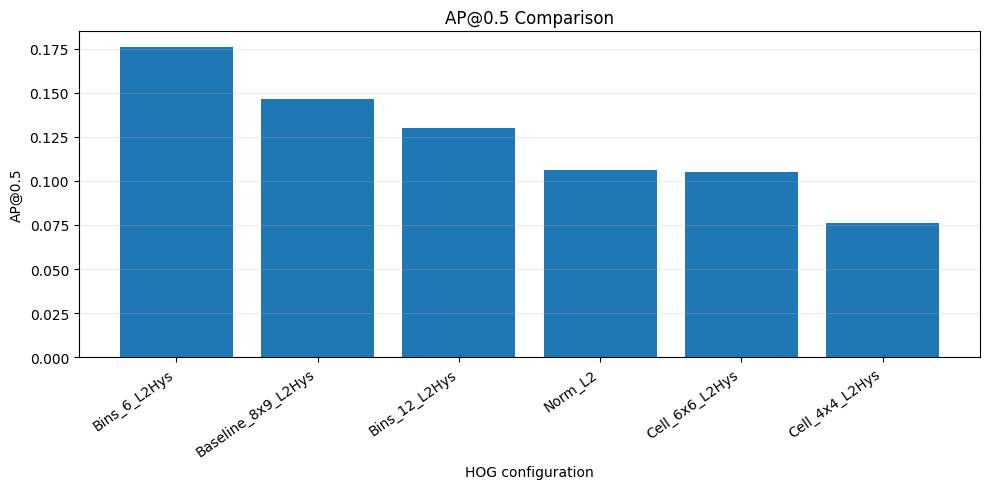

In [30]:
# ============================================================
# 17. PLOT AP COMPARISON
# ============================================================
plt.figure(figsize=(10, 5))
plt.bar(
    results_df["Experiment"],
    results_df["AP@0.5"]
)
plt.ylabel("AP@0.5")
plt.xlabel("HOG configuration")
plt.title("AP@0.5 Comparison")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

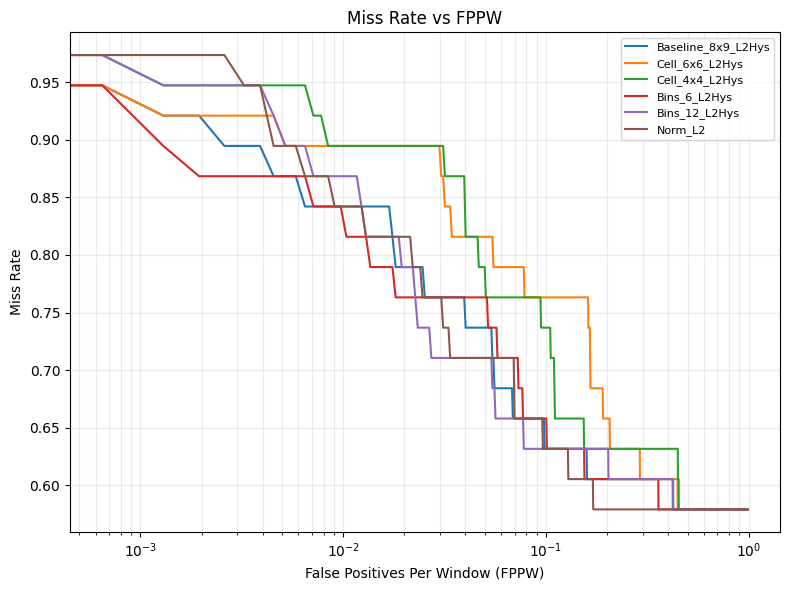

In [31]:
# ============================================================
# 18. MISS RATE vs FPPW
# ============================================================
plt.figure(figsize=(8, 6))

for name, curve in det_curves.items():
    if curve.empty:
        continue

    plt.plot(
        curve["FPPW"],
        curve["miss_rate"],
        label=name
    )

plt.xscale("log")
plt.xlabel("False Positives Per Window (FPPW)")
plt.ylabel("Miss Rate")
plt.title("Miss Rate vs FPPW")
plt.grid(True, which="both", alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Failure-case visualization


Best configuration: Bins_6_L2Hys


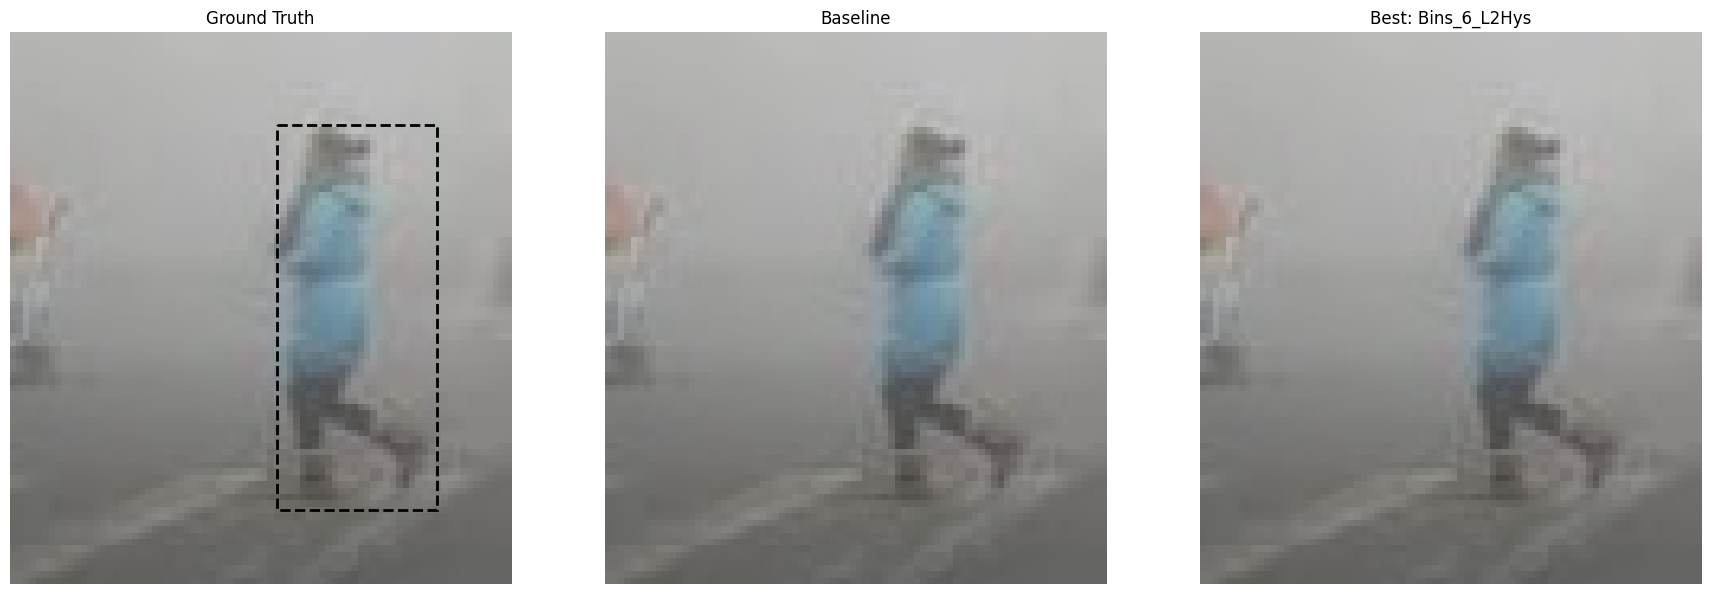

In [32]:
# ============================================================
# 19. VISUALIZATION UTILITIES
# ============================================================
def draw_boxes(
    ax,
    image,
    gt_boxes=None,
    detections=None,
    title=""
):
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(title)

    if gt_boxes:
        for b in gt_boxes:
            x1, y1, x2, y2 = b
            rect = plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                linestyle="--"
            )
            ax.add_patch(rect)

    if detections:
        for d in detections:
            x1, y1, x2, y2 = d["box"]
            score = d["score"]

            rect = plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2
            )
            ax.add_patch(rect)

            ax.text(
                x1,
                max(0, y1 - 3),
                f"{score:.2f}",
                fontsize=8,
                bbox=dict(alpha=0.7)
            )


best_name = results_df.iloc[0]["Experiment"]
baseline_name = "Baseline_8x9_L2Hys"

print("Best configuration:", best_name)

# Choose an image with at least one GT.
visual_id = next(
    i for i in test_indices
    if len(gt_by_image[i]) > 0
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

draw_boxes(
    axes[0],
    images_by_id[visual_id],
    gt_boxes=gt_by_image[visual_id],
    title="Ground Truth"
)

draw_boxes(
    axes[1],
    images_by_id[visual_id],
    detections=all_results[baseline_name]["nms"][visual_id][:10],
    title="Baseline"
)

draw_boxes(
    axes[2],
    images_by_id[visual_id],
    detections=all_results[best_name]["nms"][visual_id][:10],
    title=f"Best: {best_name}"
)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# 20. AUTOMATIC FAILURE-CASE SEARCH
# ============================================================
def count_tp_for_image(dets, gt_boxes, iou_threshold=0.5):
    matched = np.zeros(len(gt_boxes), dtype=bool)
    tp = 0

    for d in sorted(dets, key=lambda z: z["score"], reverse=True):
        if not gt_boxes:
            continue

        ious = np.asarray([
            box_iou(d["box"], g)
            for g in gt_boxes
        ])

        j = int(np.argmax(ious))

        if ious[j] >= iou_threshold and not matched[j]:
            matched[j] = True
            tp += 1

    return tp


failure_candidates = []

for image_id in test_indices:
    gt = gt_by_image[image_id]
    dets = all_results[best_name]["nms"][image_id]

    tp = count_tp_for_image(dets, gt)
    fn = max(0, len(gt) - tp)
    fp = max(0, len(dets) - tp)

    failure_candidates.append({
        "image_id": image_id,
        "GT": len(gt),
        "TP": tp,
        "FN": fn,
        "FP": fp
    })

failure_df = pd.DataFrame(failure_candidates)

print("Most false negatives:")
display(
    failure_df.sort_values(
        ["FN", "FP"],
        ascending=False
    ).head(5)
)

print("Most false positives:")
display(
    failure_df.sort_values(
        ["FP", "FN"],
        ascending=False
    ).head(5)
)

Most false negatives:


,image_id,GT,TP,FN,FP
2,2,6,1,5,8
7,7,2,0,2,58
10,10,4,2,2,17
18,18,3,1,2,3
8,8,2,0,2,2


Most false positives:


,image_id,GT,TP,FN,FP
14,14,1,0,1,95
4,4,1,0,1,64
7,7,2,0,2,58
6,6,3,3,0,47
10,10,4,2,2,17


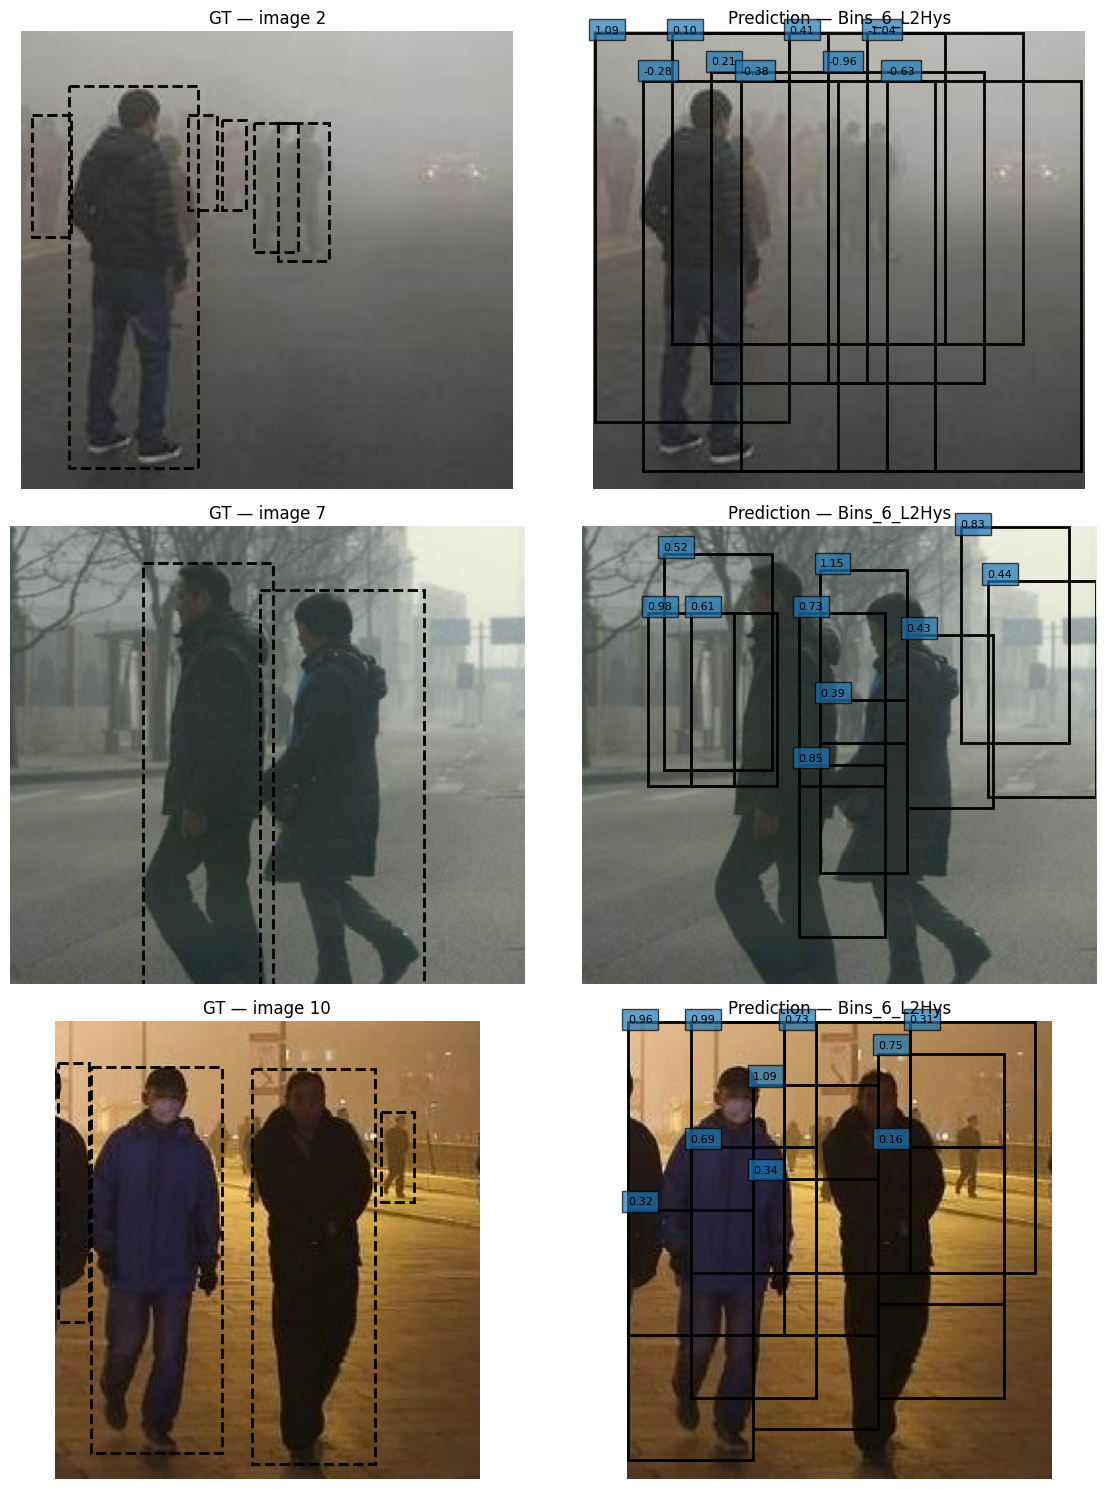

In [34]:
# ============================================================
# 21. SHOW FAILURE CASES
# ============================================================
selected_failure_ids = []

# Prefer images with FN.
for _, row in failure_df.sort_values(
    ["FN", "FP"], ascending=False
).iterrows():
    if row["FN"] > 0:
        selected_failure_ids.append(int(row["image_id"]))
    if len(selected_failure_ids) >= 3:
        break

# Fallback to highest FP cases.
if len(selected_failure_ids) < 3:
    for _, row in failure_df.sort_values(
        ["FP", "FN"], ascending=False
    ).iterrows():
        iid = int(row["image_id"])
        if iid not in selected_failure_ids:
            selected_failure_ids.append(iid)
        if len(selected_failure_ids) >= 3:
            break

fig, axes = plt.subplots(
    len(selected_failure_ids),
    2,
    figsize=(12, 5 * max(1, len(selected_failure_ids)))
)

if len(selected_failure_ids) == 1:
    axes = np.asarray([axes])

for r, image_id in enumerate(selected_failure_ids):
    draw_boxes(
        axes[r, 0],
        images_by_id[image_id],
        gt_boxes=gt_by_image[image_id],
        title=f"GT — image {image_id}"
    )

    draw_boxes(
        axes[r, 1],
        images_by_id[image_id],
        detections=all_results[best_name]["nms"][image_id][:10],
        title=f"Prediction — {best_name}"
    )

plt.tight_layout()
plt.show()

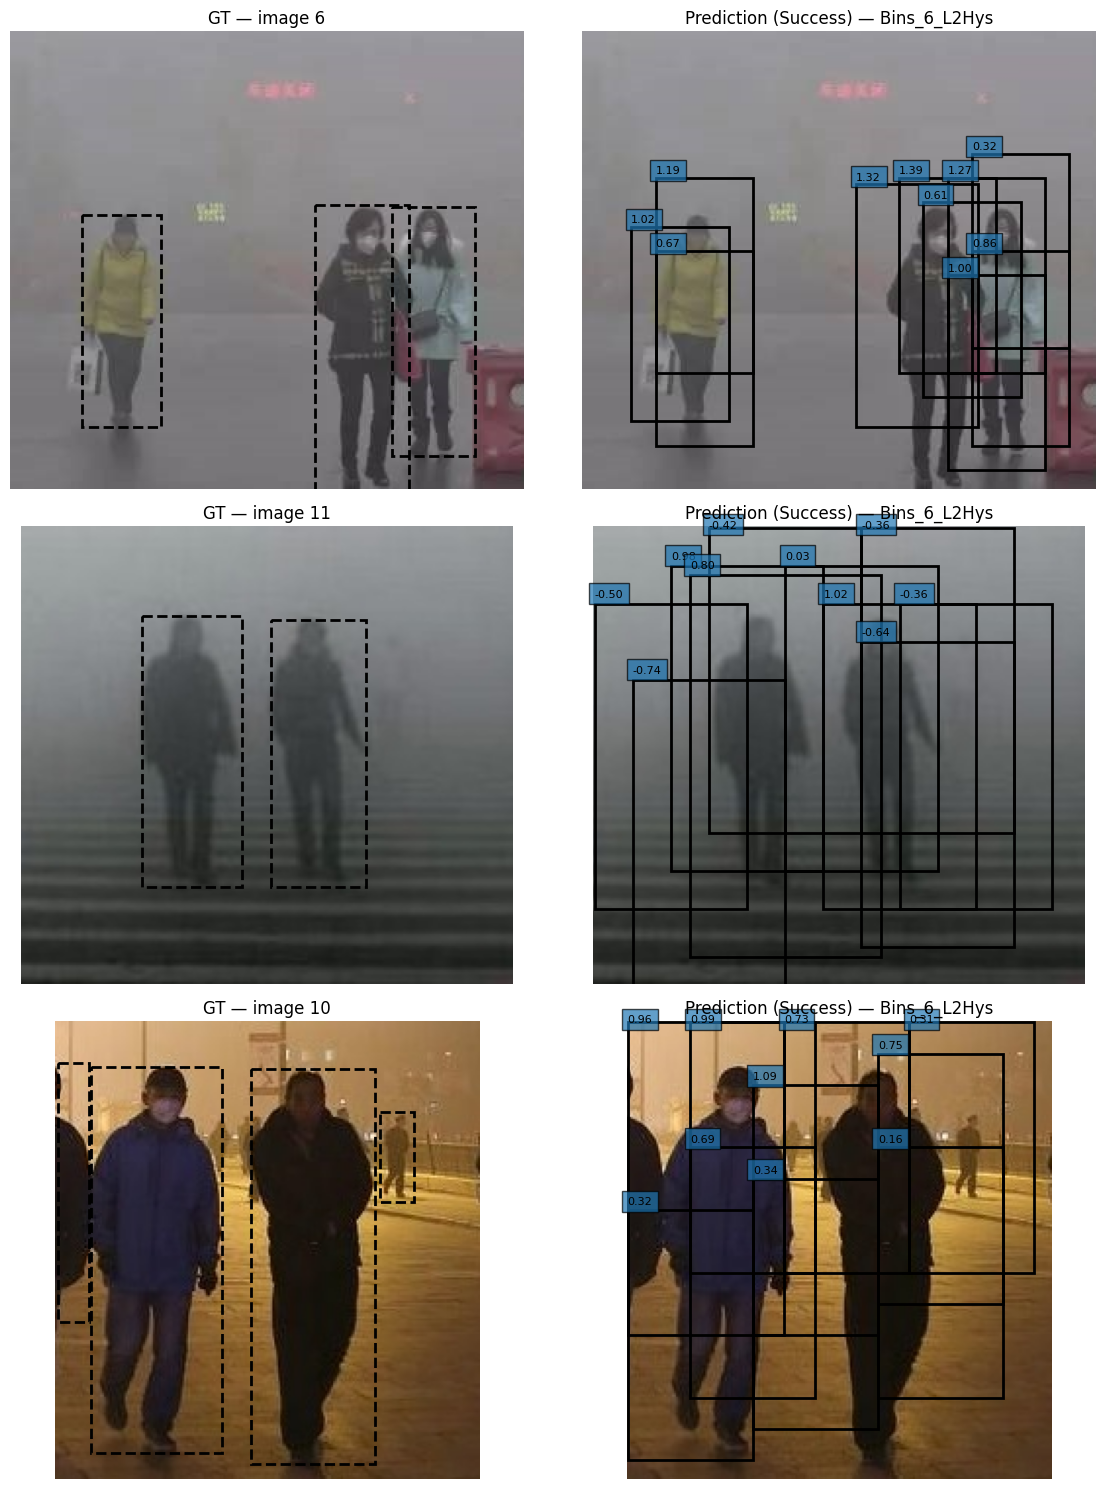

In [37]:
# ============================================================
# 21b. SHOW SUCCESS CASES (Berdasarkan True Positives Tertinggi)
# ============================================================
selected_success_ids = []

# Memprioritaskan citra dengan True Positives (TP) tertinggi,
# dengan prioritas kedua False Positives (FP) dan False Negatives (FN) terendah.
for _, row in failure_df.sort_values(
    by=["TP", "FP", "FN"], ascending=[False, True, True]
).iterrows():
    if row["TP"] > 0:
        selected_success_ids.append(int(row["image_id"]))
    if len(selected_success_ids) >= 3:
        break

# Fallback: Jika tidak ada citra dengan TP > 0 (sangat jarang terjadi),
# ambil citra apa saja yang memiliki Ground Truth (GT).
if len(selected_success_ids) < 3:
    for _, row in failure_df.sort_values(
        ["GT"], ascending=False
    ).iterrows():
        iid = int(row["image_id"])
        if iid not in selected_success_ids:
            selected_success_ids.append(iid)
        if len(selected_success_ids) >= 3:
            break

fig, axes = plt.subplots(
    len(selected_success_ids),
    2,
    figsize=(12, 5 * max(1, len(selected_success_ids)))
)

if len(selected_success_ids) == 1:
    axes = np.asarray([axes])

for r, image_id in enumerate(selected_success_ids):
    draw_boxes(
        axes[r, 0],
        images_by_id[image_id],
        gt_boxes=gt_by_image[image_id],
        title=f"GT — image {image_id}"
    )

    draw_boxes(
        axes[r, 1],
        images_by_id[image_id],
        detections=all_results[best_name]["nms"][image_id][:10],
        title=f"Prediction (Success) — {best_name}"
    )

plt.tight_layout()
plt.show()

In [35]:
RESULTS_DIR = "/content/hog_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

results_path = os.path.join(
    RESULTS_DIR,
    "hog_parameter_results.csv"
)

results_df.to_csv(results_path, index=False)

for name, curve in det_curves.items():
    safe = name.replace("/", "_")
    curve.to_csv(
        os.path.join(
            RESULTS_DIR,
            f"det_curve_{safe}.csv"
        ),
        index=False
    )

print("Saved results to:", RESULTS_DIR)
print("Main table:", results_path)

Saved results to: /content/hog_results
Main table: /content/hog_results/hog_parameter_results.csv
